In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from pathlib import Path

/home/alsayah/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/home/alsayah/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


In [ ]:
#Xeinum
#genes = pd.read_csv("/g/stegle/aalsayah/repos/data/xenium/ziniom_genes.csv")

In [55]:
slide_tag = Path("/g/stegle/aalsayah/repos/data/slidatag")

In [82]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish")

In [2]:
xeinum_path = Path("/g/stegle/aalsayah/repos/data/xenium")

In [2]:
xeinum5k_path = Path("/g/stegle/aalsayah/repos/data/xenium5k")

In [2]:
visium_path = Path("/g/stegle/aalsayah/repos/data/visiumHD")

In [ ]:
seqFISH_path = Path("/g/stegle/aalsayah/repos/data/seqFISH")

In [4]:
#adata = sc.read(merfish_path / "adata_healthy_diseased_merfish_.h5ad")

In [155]:
adata = sc.read(merfish_path / "overall_merfish.h5ad")

In [3]:
adata = sc.read(xeinum_path / "GSE294965_processed_data.h5ad")

In [124]:
adata = sc.read(xeinum5k_path / "nbl_xenium_anndata_final.h5ad")

In [84]:
adata

AnnData object with n_obs × n_vars = 228635 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [156]:
adata.obs["sample_id"].value_counts()

sample_id
R78_4C15    79891
R78_4C12    75782
R77_4C4     72962
Name: count, dtype: int64

In [20]:
pd.crosstab(adata.obs["sample"], adata.obs["Disease"])

Disease,ANCA,Cntrl,GBM,SLE
sample,,,,
X1,0,91110,0,0
X10,0,96432,0,0
X11,48112,0,0,0
X12,32416,0,0,0
X13,0,0,65073,0
...,...,...,...,...
X62,0,0,0,48047
X63,92609,0,0,0
X7,0,0,0,12181


In [157]:
adata = adata[adata.obs["sample_id"] == "R78_4C15"]

In [ ]:
#adata = sc.read(xeinum_path / "skin_adata.h5ad")

In [ ]:
#adata = sc.read(seqFISH_path / "ziniom.h5ad")

In [ ]:
#adata = sc.read(visium_path / "CRC/Visium_HD_Human_Colon_Cancer_P1_molecule_info.h5")

In [158]:
adata

View of AnnData object with n_obs × n_vars = 79891 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

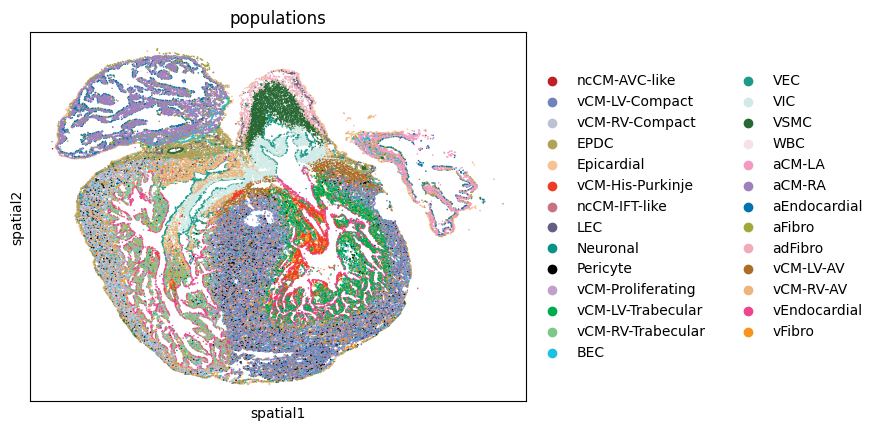

In [160]:
sc.pl.embedding(adata, basis="spatial", color="populations", s=5)  # s = point size

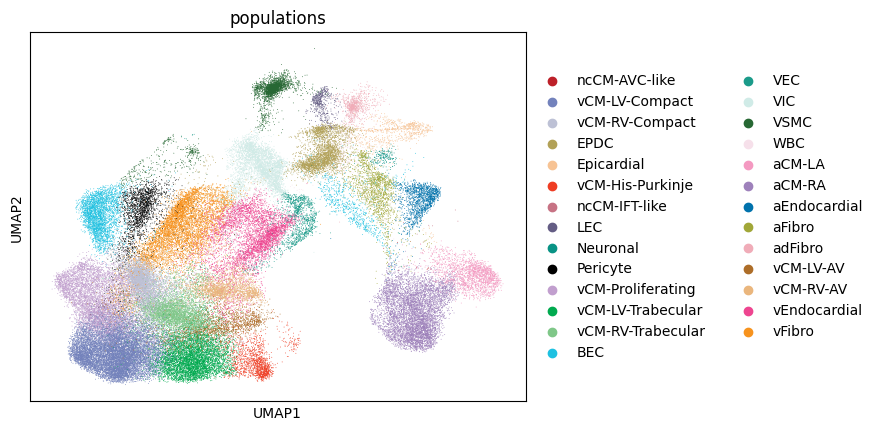

In [161]:
# Visualize on UMAP
sc.pl.umap(adata, color=["populations"])

In [ ]:
# 2) dimensionality reduction for the graph (PCA is typical)
sc.tl.pca(adata, svd_solver="arpack", n_comps=50)

# 3) neighbors graph (drives UMAP)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)  # tune n_neighbors/n_pcs

# 4) UMAP
sc.tl.umap(adata, min_dist=0.5, random_state=0)

# Visualize on UMAP
sc.pl.umap(adata, color=["cell_type"])

In [60]:
fine_to_broad = {
    'Neuron-1': 'Neuron',
    'Neuron-2': 'Neuron',
    'Neuron-3': 'Neuron',
    'Neuron-4': 'Neuron',
    'Neuron-5': 'Neuron',
    'Neuron-6': 'Neuron',
    'Neuron-7': 'Neuron',
    'Neuron-8': 'Neuron',
    'Neuron-9': 'Neuron',
    'Neuron-10': 'Neuron',
    'Neuron-11': 'Neuron',
    'Neuron-12': 'Neuron',
    'Neuron-13': 'Neuron',
    'Neuron-14': 'Neuron',
    'Neuron-15': 'Neuron',
    'Neuron-16': 'Neuron',
    'Radial glia': 'Glial',
    'White Blood Cells': 'Immune',
    'Endothelial': 'Endothelial',
    'Fibroblast': 'Fibroblast',
    'Choroid Plexus': 'Choroid Plexus'
}

In [61]:
adata.obs["cell_type_lv1"] =  adata.obs['cell_type'].map(fine_to_broad)

... storing 'cell_type_lv1' as categorical


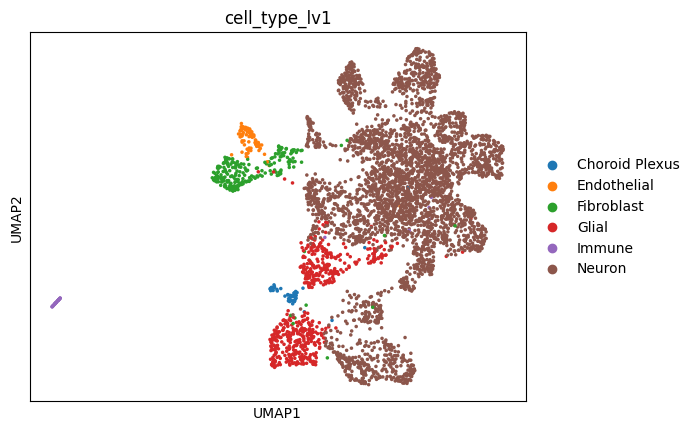

In [62]:
# Visualize on UMAP
sc.pl.umap(adata, color=["cell_type_lv1"])

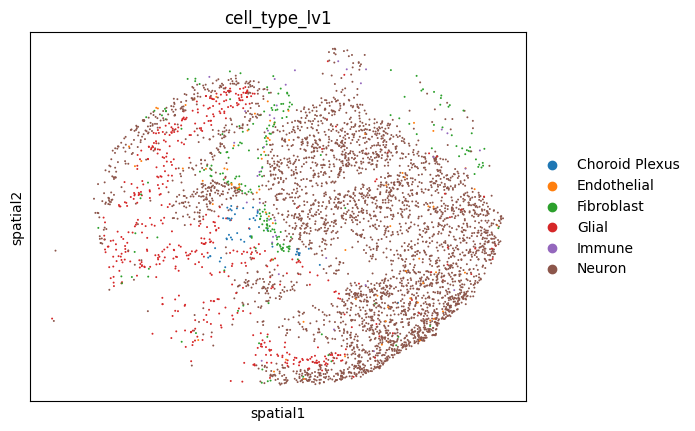

In [63]:
sc.pl.embedding(adata, basis="spatial", color="cell_type_lv1", s=8)  # s = point size

In [ ]:
import scanpy as sc

# optional: ensures points are rasterized automatically when saving vector formats (PDF/SVG)
sc.settings.set_figure_params(vector_friendly=True)

sc.pl.umap(
    adata,
    color=['cell_type'],
    size=2,
    wspace=0.3,
    ncols=2,
    frameon=False,
    # rasterized=True  # <-- remove this
)


### Check LR genes

In [28]:
lr = li.rs.select_resource('consensus')

In [29]:
resource = li.rs.select_resource('consensus')

### Mouse

In [30]:
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )

/g/stegle/aalsayah/repos/liana-py/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [31]:
map_df

,human_symbol,mouse_symbol
85,-,Bbs1
86,-,Tm9sf1
87,-,Ddx19b
88,-,Oc90
89,-,Vamp2
...,...,...
68073,ZYG11A,Zyg11a
68075,ZYG11B,Zyg11b
68077,ZYX,Zyx
68078,ZZEF1,Zzef1


In [32]:
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})

In [33]:
# We will then translate
mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
mouse

,ligand,receptor
0,Lgals9,Ptprc
1,Lgals9,Met
2,Lgals9,Cd44
3,Lgals9,Lrp1
4,Lgals9,Cd47
...,...,...
4619,Bmp2,Actr2
4620,Bmp15,Actr2
4621,Csf1,Csf3r
4622,Il36g,Ifnar1


In [ ]:
mouse.tuples = list(zip(mouse["ligand"], mouse["receptor"]))

/scratch/jobs/38328312/ipykernel_357094/3446814065.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access


In [68]:
#retrive LR database
lr = li.rs.select_resource()
ligand_set = set(lr['ligand']) #1027
receptor_set = set(lr['receptor']) #1052

### Human

In [44]:
genes = adata.var_names

In [45]:
# Convert gene list to a set for fast lookup
gene_set = set(genes)

# Filter lr_df where both ligand and receptor are in the gene list
possible_interactions = lr[
    lr['ligand'].isin(gene_set) & lr['receptor'].isin(gene_set)
]


# Get the count
interaction_count = possible_interactions.shape[0]

print(f"Number of possible interactions: {interaction_count}")


Number of possible interactions: 0


### Mouse

In [ ]:
# Convert gene list to a set for fast lookup
gene_set = set(genes)

# Filter lr_df where both ligand and receptor are in the gene list
possible_interactions = lr[
    mouse['ligand'].isin(gene_set) & mouse['receptor'].isin(gene_set)
]


# Get the count
interaction_count = possible_interactions.shape[0]

print(f"Number of possible interactions: {interaction_count}")


### Inflow

In [35]:
adata

View of AnnData object with n_obs × n_vars = 91110 × 480
    obs: 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'x_centroid', 'y_centroid', 'cell_area', 'Slide_ID', 'batch', 'Patient_Sample_ID', 'Disease', 'n_genes', 'celltype_l1', 'celltype_l1_codes', 'celltype_l1_prob', 'Biopsy_ID', 'sample', 'label', 'nichepca_domain', 'nichepca_domain_tuned', 'nichepca_glom_no', 'glom_ID', 'polygon_flags', 'is_in_polygon', 'is_in_glom', 'is_in_periglom', 'Slide_num'
    var: 'gene_ids', 'feature_types'
    uns: 'celltype_l1_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
#Extract coords and save them in obsm["spatial"], li.ut.spatial_neighbors() and squidpy functions like sq.gr.spatial_autocorr() look for spatial coordinates in adata.obsm["spatial"] by default.
coords = adata_p1.obs[['X', 'Y']].to_numpy()
adata.obsm["spatial"] = coords

In [162]:
li.ut.spatial_neighbors(adata=adata, bandwidth=30)

/g/stegle/aalsayah/repos/liana-py/liana/utils/spatial_neighbors.py:143: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.


In [163]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, n_jobs = 10,
                       show_progress_bar=True)

In [164]:
adata.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
MYH7,0.869125,0.000000e+00,6.016486e-07,0.000000e+00
MYH11,0.744210,0.000000e+00,6.016486e-07,0.000000e+00
MYH6,0.737832,0.000000e+00,6.016486e-07,0.000000e+00
LBH,0.718792,0.000000e+00,6.016486e-07,0.000000e+00
FBLN5,0.641595,0.000000e+00,6.016486e-07,0.000000e+00
...,...,...,...,...
AGPS,0.013631,0.000000e+00,6.016486e-07,0.000000e+00
CLEC10A,0.009232,0.000000e+00,6.016486e-07,0.000000e+00
IL1B,0.008936,0.000000e+00,6.016486e-07,0.000000e+00
CLSPN,0.007328,0.000000e+00,6.016486e-07,0.000000e+00


In [165]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

234

In [166]:
adata = adata[:, svgs]

In [167]:
adata

View of AnnData object with n_obs × n_vars = 79891 × 234
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors', 'moranI'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

### Mouse inflow

In [42]:
lrdata = li.mt.inflow(adata,  
                                  groupby='celltype_l1', # cell type columns        
                                  interactions=mouse.tuples,                          
                                  use_raw=False)
                                  
lrdata.shape

/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.


ValueError: Please check if appropriate organism/ID type was provided! Allowed proportion (0.98) of missing resource elements exceeded (1.00). Too few features from the resource were found in the data. [values in interactions argument] missing from var_names

### Human

In [168]:
lrdata = li.mt.inflow(adata,  
                                  groupby='populations', # cell type columns        
                                  resource_name='cellchatdb',                        
                                  use_raw=False)
                                  
lrdata.shape

/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.


(79891, 52)

## downstream analysis

In [169]:
li.mt.compute_global_score(lrdata, groupby='populations')

/g/stegle/aalsayah/repos/liana-py/liana/method/sc/_compute_global_score.py:89: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [ ]:
lrdata.uns["global_score"].sort_values('lr_mean').tail(10
                                                       )

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
970,JAG1,JAG1,NOTCH1,NOTCH1,aCM-LA,aCM-LA,0.133891
758,JAG1,JAG1,NOTCH1,NOTCH1,VSMC,VEC,0.134153
757,DLK1,DLK1,NOTCH1,NOTCH1,VIC,VEC,0.137957
838,DLK1,DLK1,NOTCH1,NOTCH1,EPDC,VSMC,0.141391
682,DLK1,DLK1,NOTCH1,NOTCH1,EPDC,BEC,0.142781
809,DLK1,DLK1,NOTCH1,NOTCH1,VIC,VIC,0.145255
430,JAG1,JAG1,NOTCH1,NOTCH1,Neuronal,Neuronal,0.145990
1174,JAG1,JAG1,NOTCH1,NOTCH1,VSMC,adFibro,0.160439
863,DLK1,DLK1,NOTCH1,NOTCH1,VSMC,VSMC,0.162226
1126,JAG1,JAG1,NOTCH1,NOTCH1,aCM-LA,aFibro,0.162530


In [171]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [172]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

52

In [173]:
lrdata = lrdata[:, svis]

In [174]:
lrdata

View of AnnData object with n_obs × n_vars = 79891 × 52
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors', 'moranI', 'global_score'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

In [175]:
lrdata.layers['transformed'] = li.utils.zi_minmax(lrdata.X, cutoff=0.01)

/scratch/jobs/38328312/ipykernel_357094/447211400.py:1: ImplicitModificationWarning: Setting element `.layers['transformed']` of view, initializing view as actual.


# Explore LR data object

In [176]:
lrdata

AnnData object with n_obs × n_vars = 79891 × 52
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors', 'moranI', 'global_score'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'transformed'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

In [177]:
lrdata.var_names

Index(['VIC^DLK1^NOTCH1', 'VIC^JAG1^NOTCH1', 'EPDC^JAG1^NOTCH1',
       'EPDC^DLK1^NOTCH1', 'VEC^JAG1^NOTCH1', 'LEC^DLK1^NOTCH1',
       'VEC^DLK1^NOTCH1', 'LEC^JAG1^NOTCH1', 'VSMC^JAG1^NOTCH1',
       'BEC^JAG1^NOTCH1', 'BEC^DLK1^NOTCH1', 'vEndocardial^JAG1^NOTCH1',
       'adFibro^DLK1^NOTCH1', 'adFibro^JAG1^NOTCH1', 'Neuronal^JAG1^NOTCH1',
       'aFibro^JAG1^NOTCH1', 'Neuronal^DLK1^NOTCH1', 'aFibro^DLK1^NOTCH1',
       'VSMC^DLK1^NOTCH1', 'WBC^DLK1^NOTCH1', 'aEndocardial^JAG1^NOTCH1',
       'Epicardial^DLK1^NOTCH1', 'vEndocardial^DLK1^NOTCH1',
       'Epicardial^JAG1^NOTCH1', 'vCM-RV-AV^JAG1^NOTCH1',
       'vCM-RV-AV^DLK1^NOTCH1', 'vCM-RV-Trabecular^JAG1^NOTCH1',
       'WBC^JAG1^NOTCH1', 'vCM-LV-Trabecular^JAG1^NOTCH1',
       'vCM-LV-Trabecular^DLK1^NOTCH1', 'vCM-RV-Compact^JAG1^NOTCH1',
       'aCM-RA^DLK1^NOTCH1', 'vCM-His-Purkinje^JAG1^NOTCH1',
       'aCM-RA^JAG1^NOTCH1', 'aCM-LA^DLK1^NOTCH1', 'ncCM-IFT-like^JAG1^NOTCH1',
       'aEndocardial^DLK1^NOTCH1', 'vCM-RV-Trabecula

In [178]:
interaction = "EPDC^DLK1^NOTCH1"
cell_type_col = "populations"
comp = interaction.split("^")

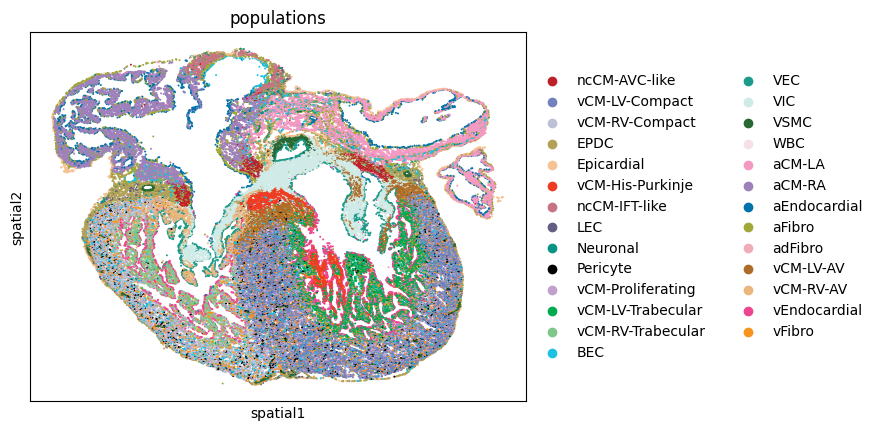

In [117]:
sc.pl.embedding(adata, basis="spatial", color=cell_type_col, s=8)  # s = point size

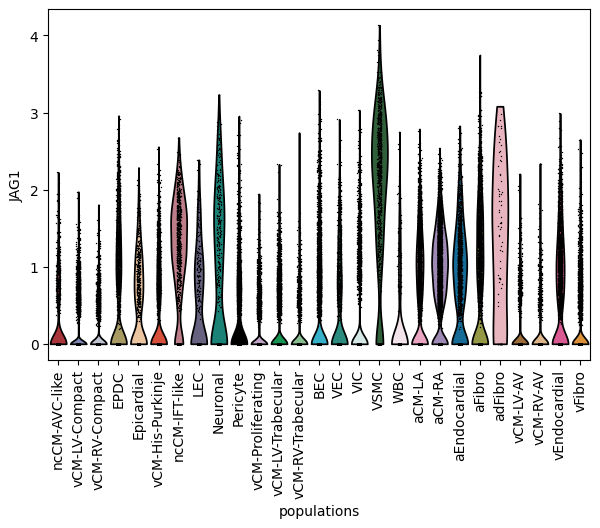

In [132]:
ax = sc.pl.violin(
    adata,
    keys="JAG1",
    groupby=cell_type_col,
    show=False  # prevent immediate display
)

import matplotlib.pyplot as plt
plt.xticks(rotation=90)  # rotate x-axis labels
plt.show()

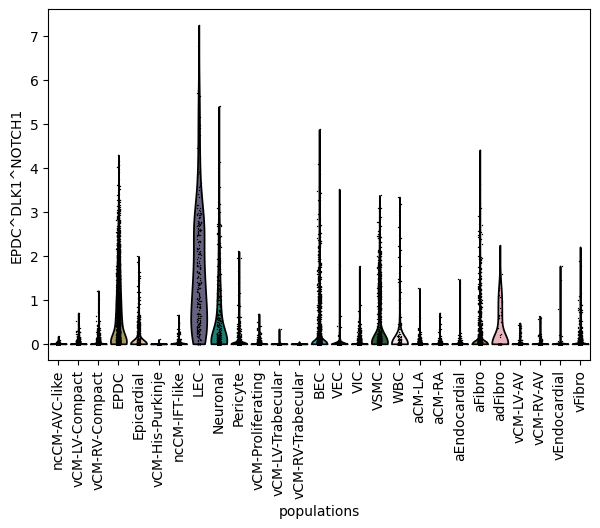

In [119]:
ax = sc.pl.violin(
    lrdata,
    keys=interaction,
    groupby=cell_type_col,
    show=False  # prevent immediate display
)

import matplotlib.pyplot as plt
plt.xticks(rotation=90)  # rotate x-axis labels
plt.show()

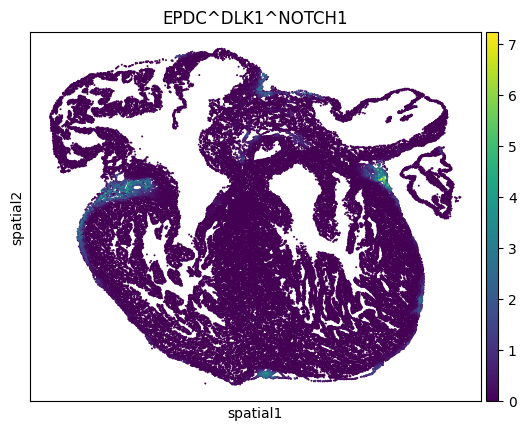

In [120]:
sc.pl.embedding(lrdata, basis="spatial", color=interaction, s=8)  # s = point size

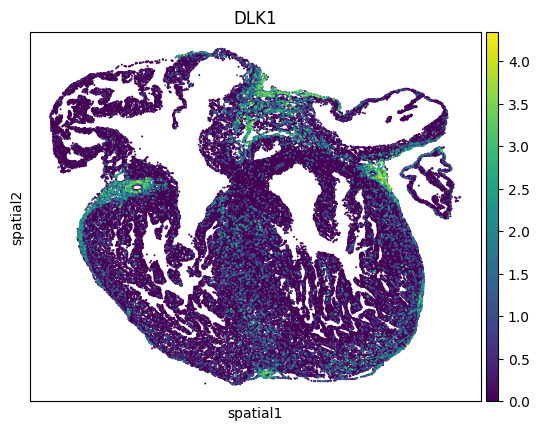

In [126]:
sc.pl.embedding(adata, basis="spatial", color=comp[1], s=8)  # s = point size

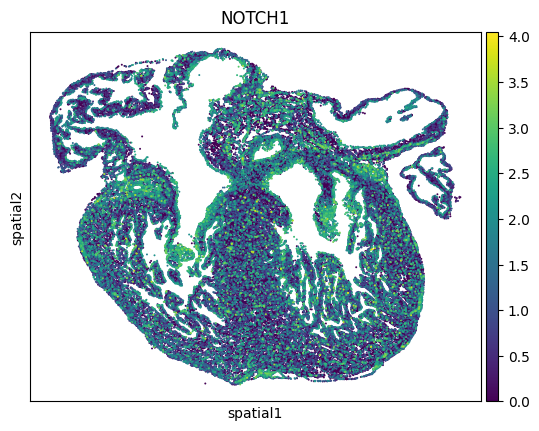

In [127]:
sc.pl.embedding(adata, basis="spatial", color=comp[2], s=8)  # s = point size

In [179]:
%%time
# PCA for dimension reduction further by UMAP for downstream analysis
sc.pp.pca(lrdata, n_comps=30)
sc.pp.neighbors(lrdata, metric="cosine")

CPU times: user 7.14 s, sys: 2.01 ms, total: 7.14 s
Wall time: 6.98 s


In [180]:
%%time
sc.tl.umap(lrdata)

CPU times: user 1min 46s, sys: 33 ms, total: 1min 46s
Wall time: 1min 37s


In [181]:
adata

View of AnnData object with n_obs × n_vars = 79891 × 234
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors', 'moranI'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

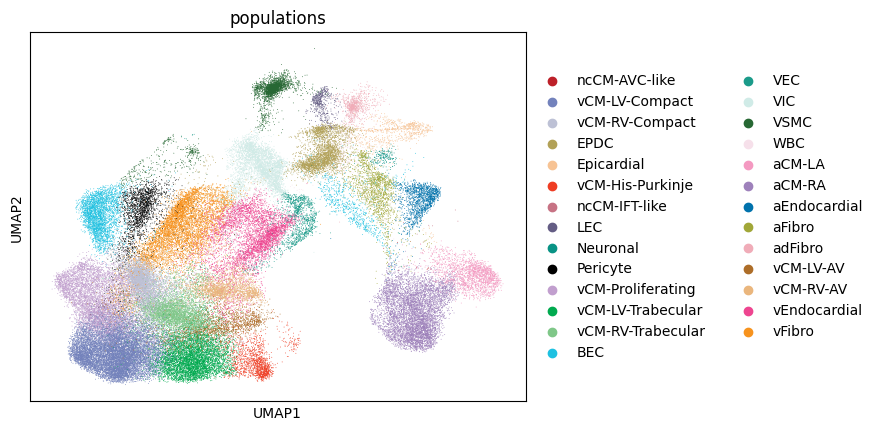

In [182]:
sc.pl.umap(adata, color="populations")

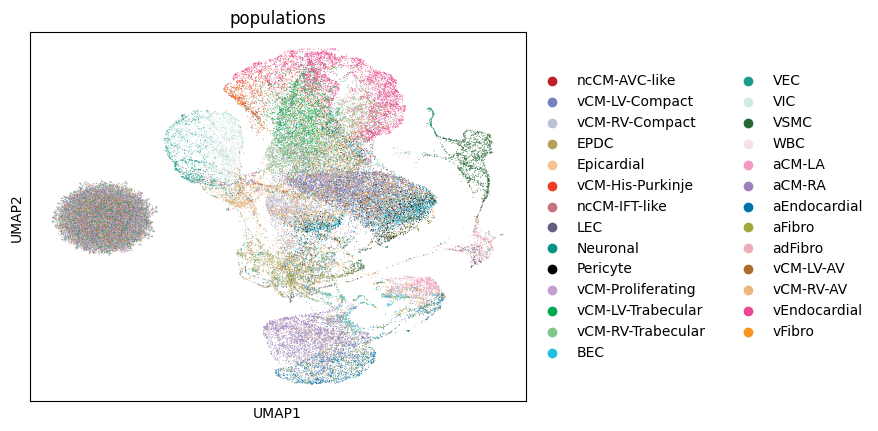

In [183]:
sc.pl.umap(lrdata, color="populations")

In [185]:
lrdata

AnnData object with n_obs × n_vars = 79891 × 52
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors', 'moranI', 'global_score'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'transformed'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

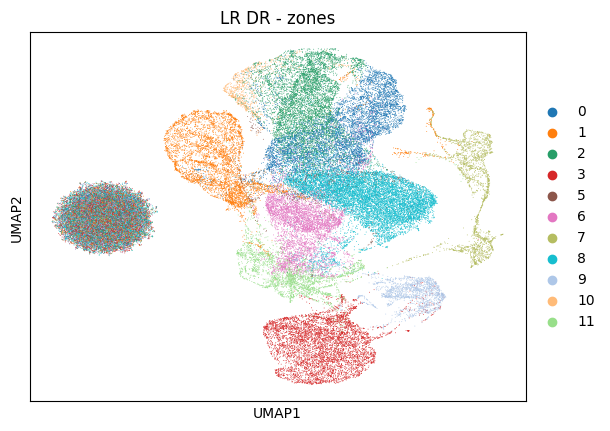

In [189]:
sc.pl.umap(lrdata, color="zone_cluster", title = "LR DR - zones")

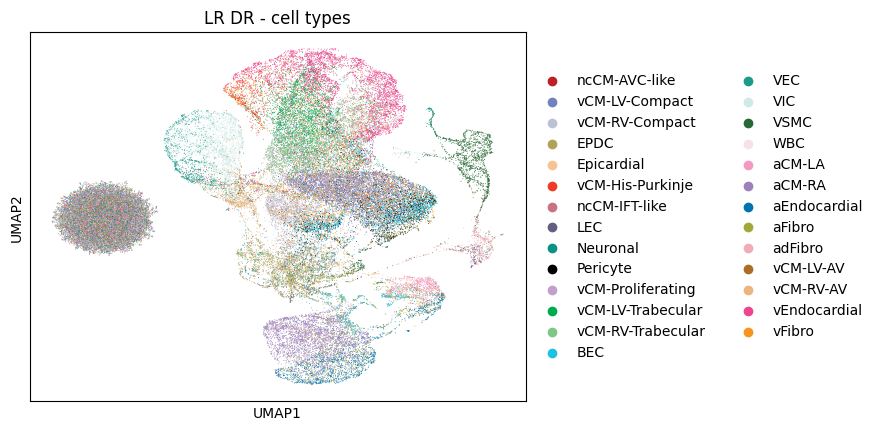

In [190]:
sc.pl.umap(lrdata, color=cell_type_col, title = "LR DR - cell types")

In [ ]:
cell_type_col

/home/alsayah/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/home/alsayah/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/home/alsayah/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

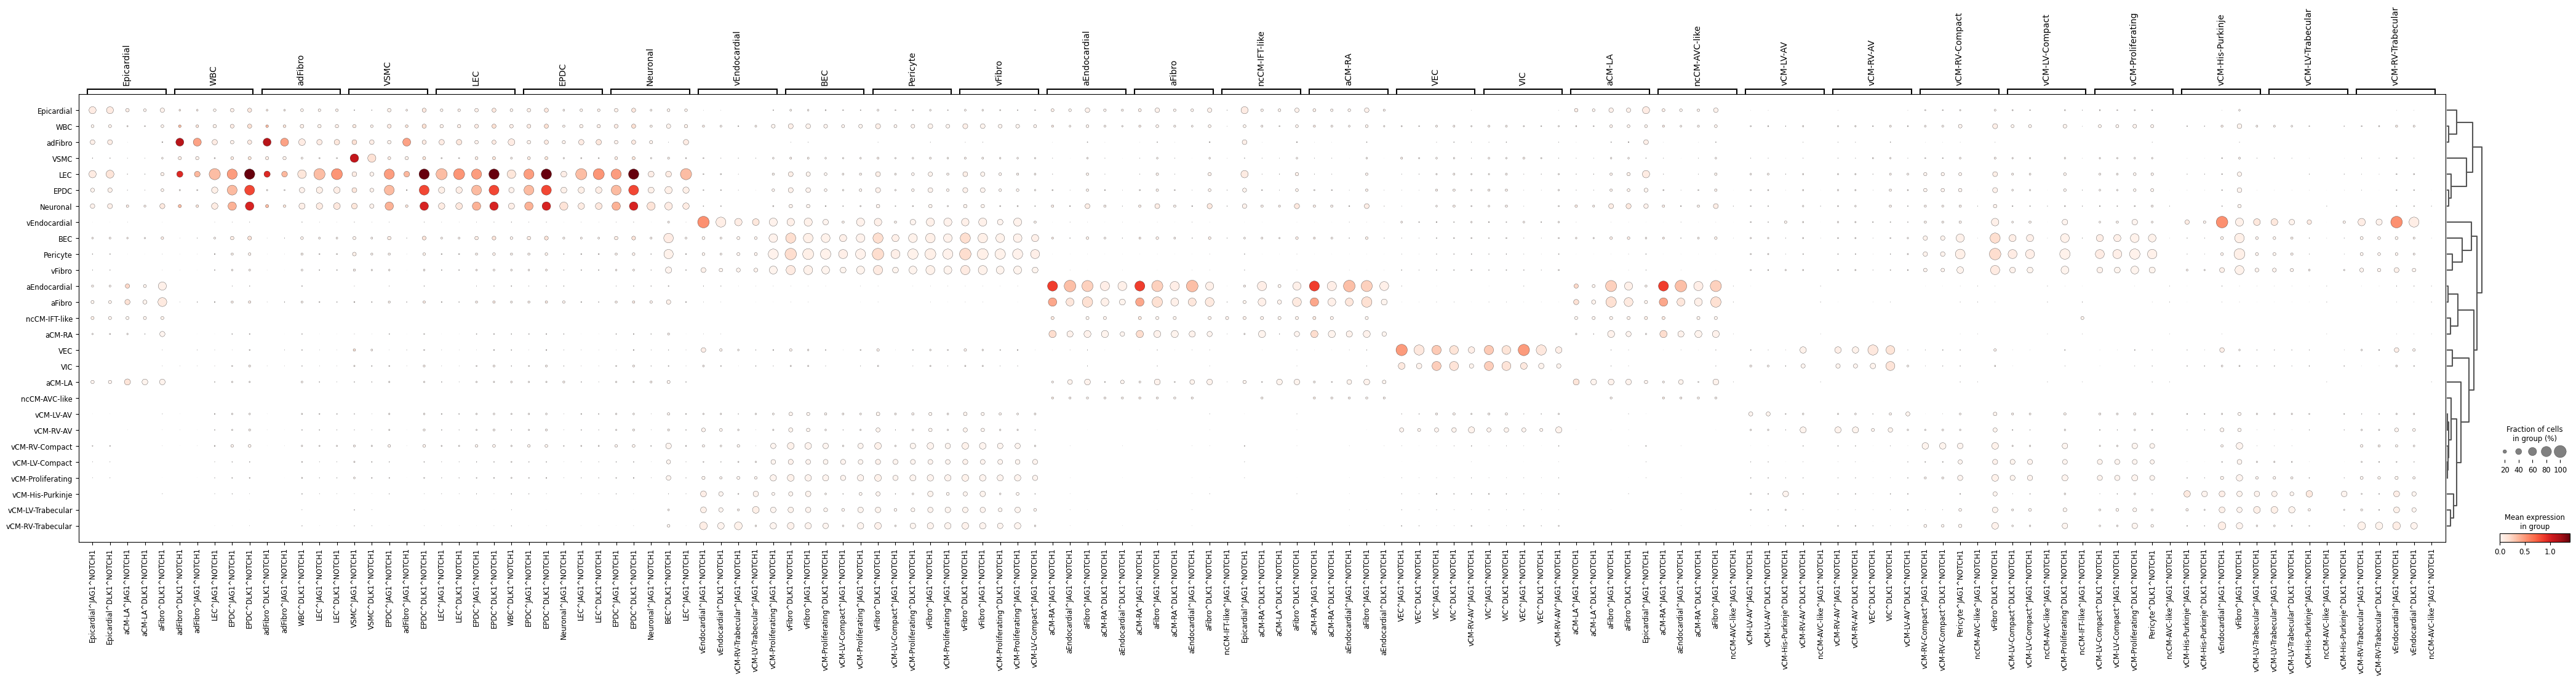

In [187]:
sc.tl.rank_genes_groups(lrdata, groupby=cell_type_col, layer="transformed", pts=True)
sc.pl.rank_genes_groups_dotplot(lrdata, n_genes=5)

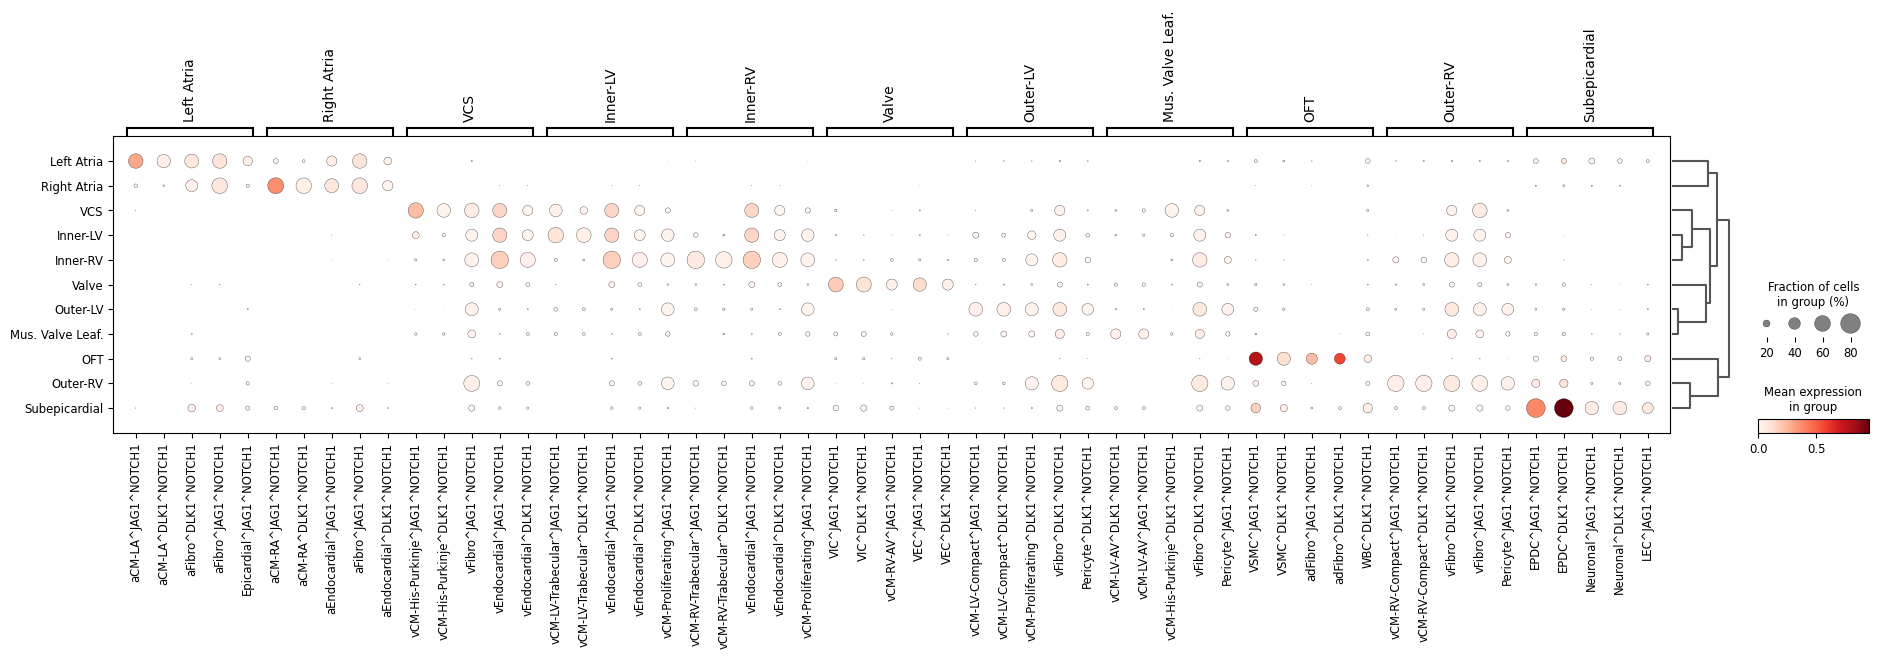

In [188]:
sc.tl.rank_genes_groups(lrdata, groupby="communities", layer="transformed", pts=True)
sc.pl.rank_genes_groups_dotplot(lrdata, n_genes=5)

In [89]:
# 2) dimensionality reduction for the graph (PCA is typical)
sc.tl.pca(lrdata, svd_solver="arpack", n_comps=50)

# 3) neighbors graph (drives UMAP)
sc.pp.neighbors(lrdata, n_neighbors=15, n_pcs=30)  # tune n_neighbors/n_pcs

# 4) UMAP
sc.tl.umap(lrdata, min_dist=0.5, random_state=0)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.


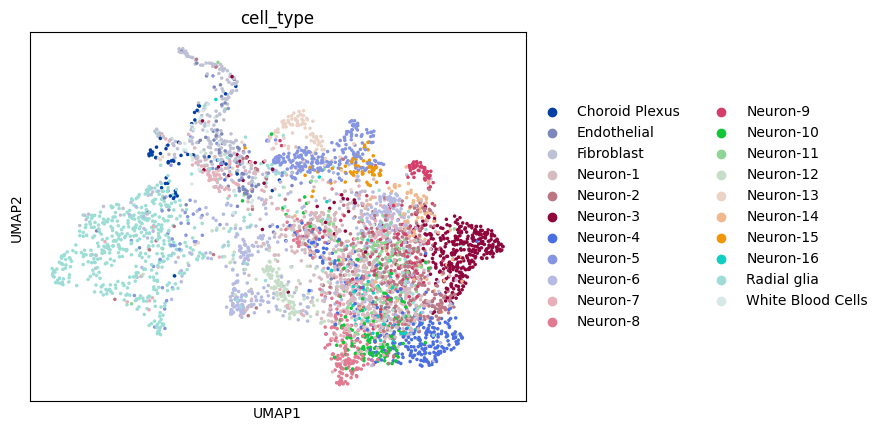

In [90]:
sc.pl.umap(lrdata, color=["cell_type"])

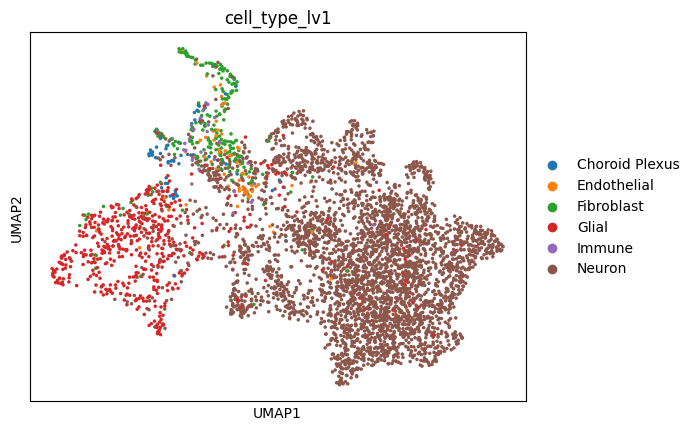

In [91]:
# Visualize on UMAP
sc.pl.umap(lrdata, color=["cell_type_lv1"])

In [133]:
slide_tag

PosixPath('/g/stegle/aalsayah/repos/data/slidatag')

In [92]:
lrdata.write_h5ad(slide_tag / "slidetags/lrdata/SCP2170_wide_anno.h5ad")